In [1]:
import concurrent.futures
import time
import glob

from scipy import ndimage
from scipy.optimize import curve_fit

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyvo
from astropy.coordinates import SkyCoord
from astropy.io import fits
from astropy.table import Table
from astropy.wcs import WCS
import shutil

In [196]:
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C

def spectrum(ra_points, dec_points, folder, aper=False):
    allfiles = glob.glob(f'{folder}/*.fits')

    wavemap3d = np.zeros((len(ra_points), len(dec_points), len(allfiles)))
    specmap3d = np.zeros((len(ra_points), len(dec_points), len(allfiles)))
    specmap3d[:,:,:] = np.nan
    taumap = np.zeros((len(ra_points), len(dec_points)))
    contmap = np.zeros((len(ra_points), len(dec_points)))
    
    for a in range(len(allfiles)):
        hdulist = fits.open(allfiles[a])
        img = hdulist[1].data
        wave = hdulist[6].data
        err = np.sqrt(hdulist[3].data)
        spectral_image_header = hdulist[1].header
        wcs = WCS(spectral_image_header)
        ra, dec = wcs.wcs.crval
        x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
        spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")
    
        spectral_wcs.sip = None
        wl, bw = spectral_wcs.pixel_to_world(x, y)
        spectral_image = hdulist["IMAGE"]
        spectral_image_data = spectral_image.data
        (y, x) = np.indices(spectral_image.shape)
        spectral_coords = spectral_wcs.pixel_to_world(x, y)
        wavelength, bandwidth = spectral_coords

        img = hdulist[1].data
        arr = img.copy()

        for m in range(len(ra_points)):
            for n in range(len(dec_points)):
                ww, ff, ee = [], [], []
                ra_target = ra_points[m]
                dec_target = dec_points[n]
                coord = SkyCoord(ra=ra_target*u.deg, dec=dec_target*u.deg, frame="icrs") 
                x, y = wcs.world_to_pixel(coord)
                p1, p2 = int(x-80), int(x+80)
                try: 
                    flux = img[int(y+0.5),p1:p2]
                    ferr = err[int(y+0.5),p1:p2]
                    if aper:
                        flux = np.mean(img[int(y+0.5)-2:int(y+0.5)+3, p1:p2], axis=0)
                    lam = wavelength.value[int(y+0.5),int(x+0.5)]
                    #print(y, x, lam)
                    sm = 1
                    flux = ndimage.gaussian_filter1d(flux, sm)
                    ferr = ndimage.gaussian_filter1d(ferr, sm) / np.sqrt(2*np.sqrt(np.pi)*sm)
                    if aper: ff.append(np.mean(flux[78:83]))
                    else: specmap3d[m,n,a] = flux[80]
                    wavemap3d[m,n,a] = lam
                except: 
                    continue

    for m in range(len(ra_points)):
        for n in range(len(dec_points)):
            try: 
                ww, ff = np.array(wavemap3d[m,n,:]), np.array(specmap3d[m,n,:])
                ww, ff = np.sort(ww), ff[np.argsort(ww)]
                mask1 = np.where((ww < 2.7) | (ww > 3.4))[0]
                contmap[m,n] = np.nanmedian(ff[mask1])
            except: contmap[m,n] = -1
            try:
                ww, ff = np.array(wavemap3d[m,n,:]), np.array(specmap3d[m,n,:])
                ww, ff = np.sort(ww), ff[np.argsort(ww)]
                mask1 = np.where((ww < 2.7) | (ww > 3.4))[0]
                ff /= np.nanmedian(ff[mask1])
                mask2 = np.where((ff > 1.5) | (ff < 0.2))
                ff[mask2] = np.nan 
                mask3 = np.isnan(ff)
                ww, ff = ww[~mask3], ff[~mask3]
    
                mask4 = np.where((ww <= 2.7) | (ww >= 3.35))[0]
                popt, pcov = curve_fit(cont_fit, ww[mask4], ff[mask4])
                mask5 = np.where((ww >= 2.9) & (ww <= 3.1))[0]
                taumap[m,n] = -np.log(np.nanmedian(ff[mask5]) / np.nanmedian(cont_fit(ww[mask5], *popt)))
            except:
                continue
    return taumap, contmap

## CrA 151 - prestellar:

In [172]:
ra_points = np.arange(287.5857417-0.0025*30, 287.5857417+0.0025*30, 0.0025)
dec_points = np.arange(-37.1408333-0.002*30, -37.1408333+0.002*30, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'CrA-151-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

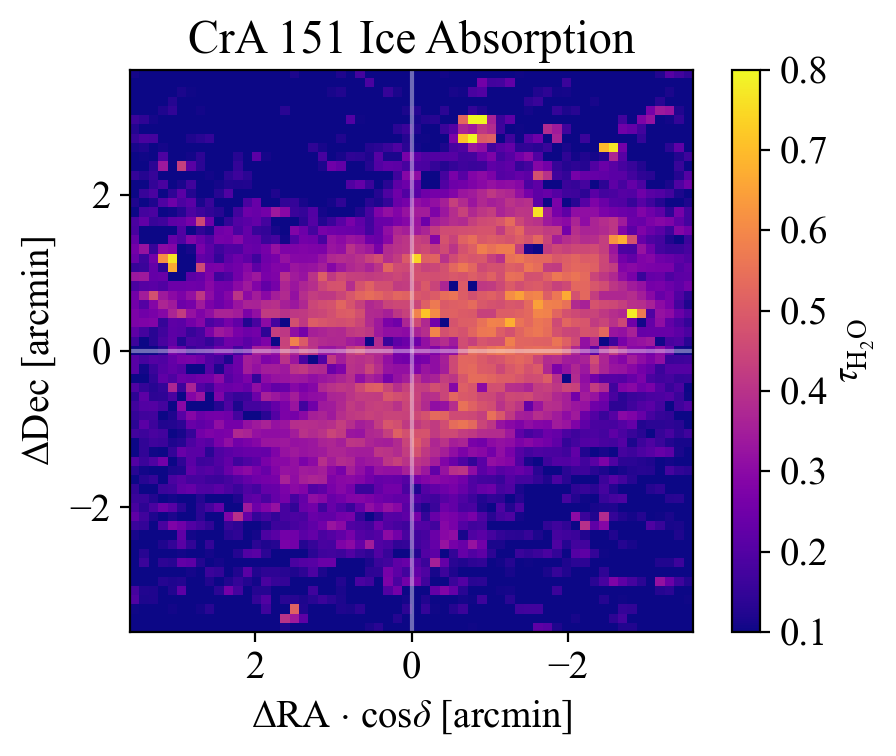

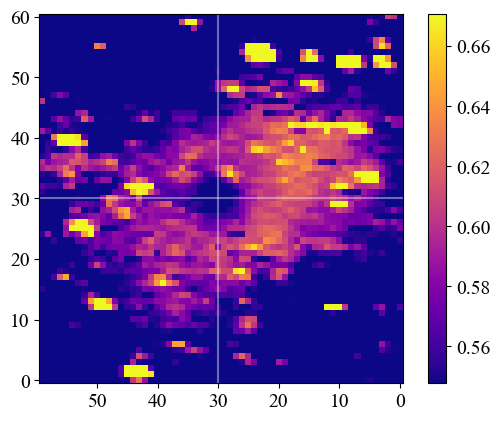

In [174]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.1, vmax=0.8, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('CrA 151 Ice Absorption')
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/CrA-151-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

### old

In [1510]:
rlist = [287.5857417, 287.5857417-0.017, 287.5857417+0.0153]
dlist = [-37.1408333, -37.1408333, -37.1408333, -37.1408333]

w1, f1, e1 = spectrum(287.5857417, -37.1408333, 'CrA-151-SPHEREx')
w2, f2, e2 = spectrum(287.5857417-0.017, -37.1408333, 'CrA-151-SPHEREx')
w3, f3, e3 = spectrum(287.5857417+0.015, -37.1408333, 'CrA-151-SPHEREx')

w4, f4, e4 = spectrum(287.5857417-0.02*2, -37.1408333, 'CrA-151-SPHEREx')
w5, f5, e5 = spectrum(287.5857417+0.018*2, -37.1408333, 'CrA-151-SPHEREx')

#w4, f4 = spectrum(287.5857417, -37.1208333, 'CrA-151-SPHEREx')
#w5, f5 = spectrum(287.5857417, -37.1608333, 'CrA-151-SPHEREx')
#w4, f4 = spectrum(287.5857417+0.16/2, -37.1408333, 'CrA-151-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
656.5532325833715 83

tau =  0.13809737880588455
tau =  0.22048352133369165
tau =  0.20024261269967508
tau =  0.16558209158570888
tau =  0.1583048174975298


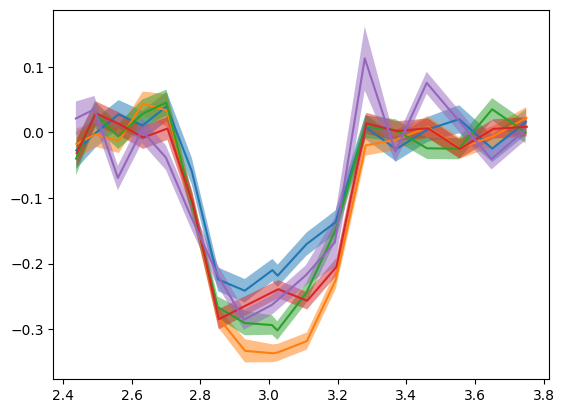

In [1511]:
f1[10] = f2[10] = f3[10] = f5[10] = np.nan
f4[8] = f4[7] = f4[9] = np.nan
f5[-3] = np.nan

for ww, ff, ee in zip([w1, w2, w3, w4, w5], [f1, f2, f3, f4, f5], [e1, e2, e3, e4, e5]):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    print('tau = ',-np.log10(np.nanmin(fv) / cont_fit(wv[np.nanargmin(fv)],*popt)))

tau =  0.13809737880588455
tau =  0.22048352133369165
tau =  0.20024261269967508
tau =  0.16558209158570888
tau =  0.1583048174975298


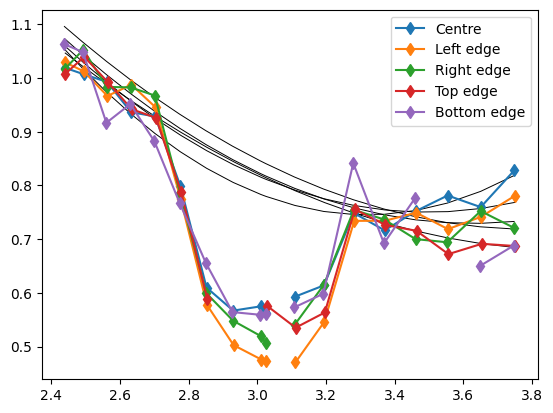

In [1434]:
f1[10] = f2[10] = f3[10] = f5[10] = np.nan
f4[8] = f4[7] = f4[9] = np.nan
f5[-3] = np.nan

for ww, ff, ee in zip([w1, w2, w3, w4, w5], [f1, f2, f3, f4, f5], [e1, e2, e3, e4, e5]):
    mask = np.isnan(ff)
    ww, ff, ee = ww[~mask], ff[~mask], ee[~mask]

for ww, ff in zip([w1, w2, w3, w4, w5], [f1, f2, f3, f4, f5]):
    wv, fv = ww.copy(), ff.copy()
    mask = np.where(((wv <= 2.7) | (wv >= 3.3)) & ~np.isnan(fv))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[:5]), color='k', lw=0.7)
    print('tau = ',-np.log10(np.nanmin(fv) / cont_fit(wv[np.nanargmin(fv)],*popt)))

plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='', label='Centre')
plt.plot(w2, f2/np.nanmedian(f2[:4]), marker='', label='Left edge')
plt.plot(w3, f3/np.nanmedian(f3[:4]), marker='', label='Right edge')
plt.plot(w4, f4/np.nanmedian(f4[:4]), marker='d', label='Top edge')
plt.plot(w5, f5/np.nanmedian(f5[:4]), marker='d', label='Bottom edge')
plt.legend()

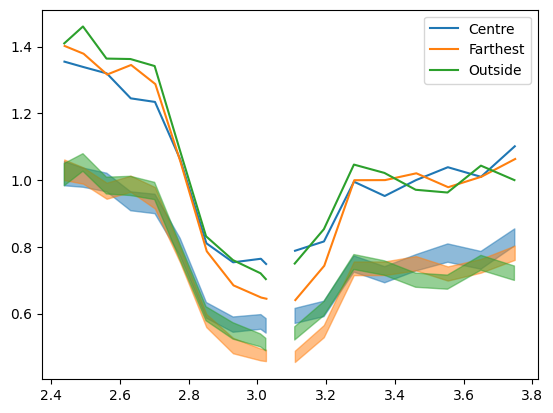

In [1436]:
plt.plot(w1, f1/np.nanmedian(f1[-7:]), marker='', label='Centre')
plt.fill_between(w1, (f1-e1)/np.nanmedian(f1[:4]), (f1+e1)/np.nanmedian(f1[:4]), color='C0', alpha=0.5)
plt.plot(w2, f2/np.nanmedian(f2[-7:]), marker='', label='Farthest')
plt.fill_between(w2, (f2-e2)/np.nanmedian(f2[:4]), (f2+e2)/np.nanmedian(f2[:4]), color='C1', alpha=0.5)
plt.plot(w3, f3/np.nanmedian(f3[-7:]), marker='', label='Outside')
plt.fill_between(w3, (f3-e3)/np.nanmedian(f3[:4]), (f3+e3)/np.nanmedian(f3[:4]), color='C2', alpha=0.5)
plt.legend()

## L1544 - prestellar:

In [145]:
ra_points = np.arange(76.0697917-0.0023*30, 76.0697917+0.0023*30, 0.0023)
dec_points = np.arange(25.18125-0.002*30, 25.18125+0.002*30, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'L1544-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

In [144]:
import warnings
from matplotlib import rcParams
# Ignore all warnings
warnings.filterwarnings('ignore')
rcParams.update({
    'font.family': 'serif',
    'font.serif': ['Times New Roman'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Times New Roman',
    'mathtext.it': 'Times New Roman:italic',
    'mathtext.bf': 'Times New Roman:bold',
    'font.size': 14
})

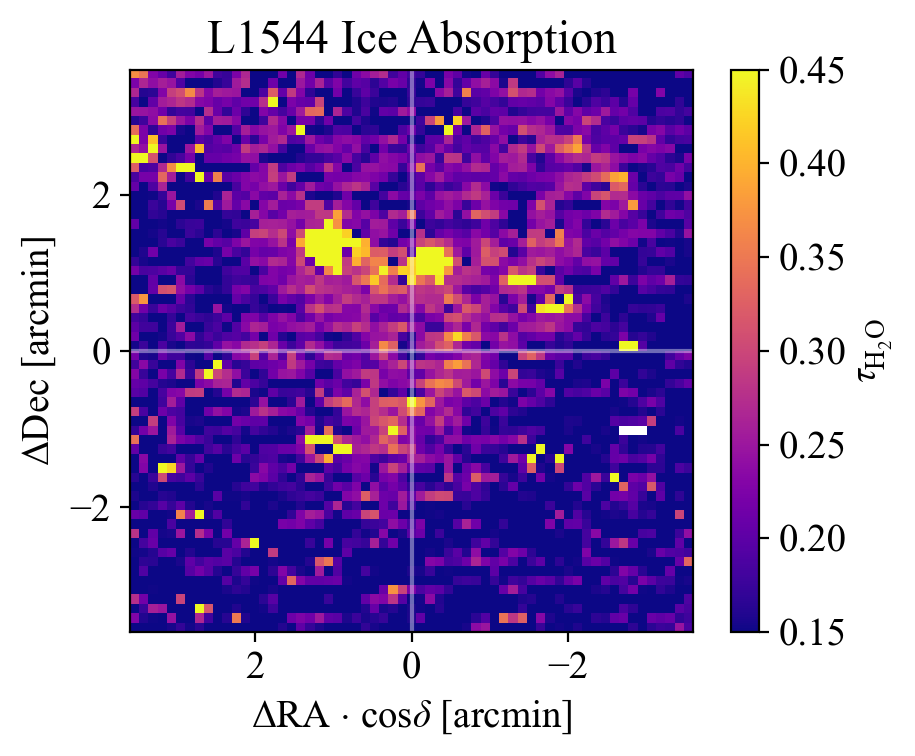

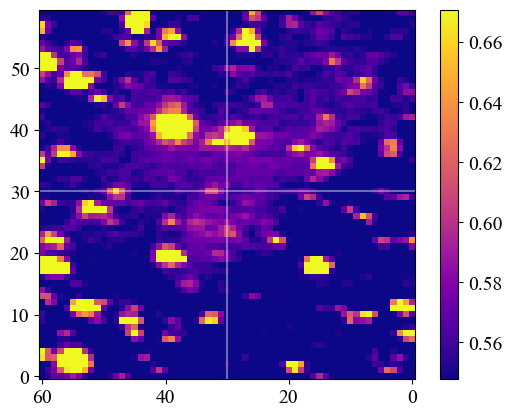

In [162]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.15, vmax=0.45, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('L1544 Ice Absorption')
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/L1544-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

## L1512 - prestellar:

In [163]:
ra_points = np.arange(76.0364167-0.0024*30, 76.0364167+0.0024*30, 0.0024)
dec_points = np.arange(32.7211667-0.002*30, 32.7211667+0.002*30, 0.002)

tau = spectrum(ra_points, dec_points, 'L1512-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

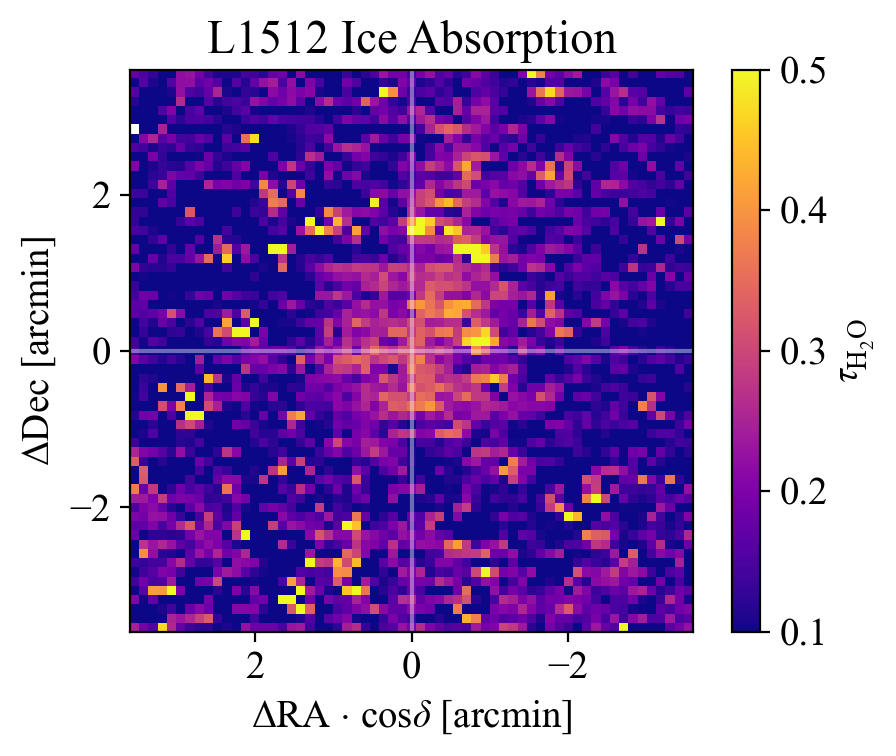

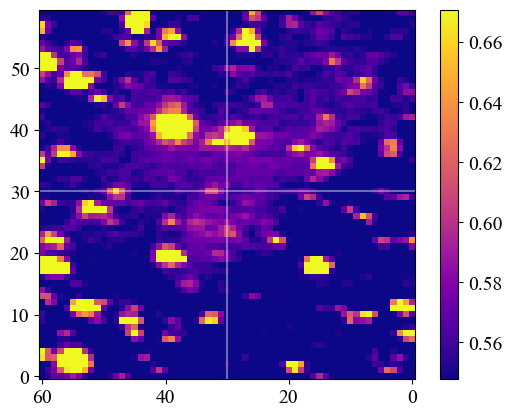

In [167]:
tt = tau[0].copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.1, vmax=0.5, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('L1512 Ice Absorption')
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/L1512-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

### older:

In [1447]:
rlist = [76.0324167, 76.0434167, 76.0544167]   
dlist = [32.7311667, 32.7301667, 32.7281667]

w1, f1 = spectrum(rlist[0], dlist[0], 'L1512-SPHEREx', aper=False)
w2, f2 = spectrum(rlist[1], dlist[1], 'L1512-SPHEREx', aper=False)
w3, f3 = spectrum(rlist[2], dlist[2], 'L1512-SPHEREx', aper=False)
#w4, f4 = spectrum(rlist[3], dlist[3], 'LDN183-SPHEREx', aper=False)

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1068.464270774296 51

ValueError: too many values to unpack (expected 2)

tau =  0.06918624105646468
tau =  0.11633260577483989
tau =  0.09931462159125558


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/3398435754.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


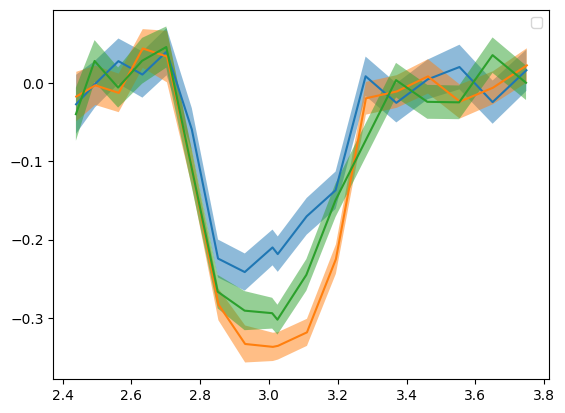

In [1449]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
#f1[8] = f2[9] = f1[10] = np.nan
f3[-6] = np.nan

for ww, ff, ee in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3]):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    mask = np.where(((wv <= 2.95) | (wv >= 3.05)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[~mask] / cont_fit(wv[~mask],*popt))
    #plt.plot(wv, (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:5]), marker='d')
    print('tau = ',np.nanmean(tau_all))

if 0:
    plt.plot(w1, f1/np.nanmedian(f1[:7]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[:7]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[:7]), marker='d', label='Outskirts')
#plt.plot(w4, f4/np.nanmedian(f4[:4]), marker='d', label='Outskirts')
plt.legend()
#plt.ylim(0,1.5)

## RCrA IRS 7B - bright YSO

In [177]:
ra_points = np.arange(285.4602500-0.0024*50, 285.4602500+0.0024*50, 0.0024)
dec_points = np.arange(-36.9362500-0.002*50, -36.9362500+0.002*50, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'RCrA-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

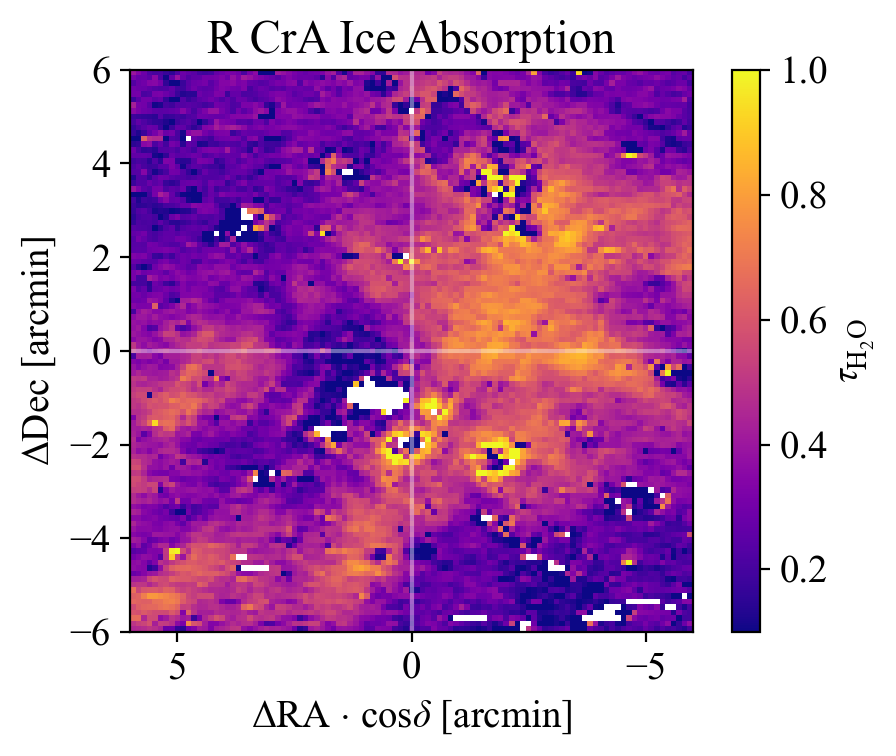

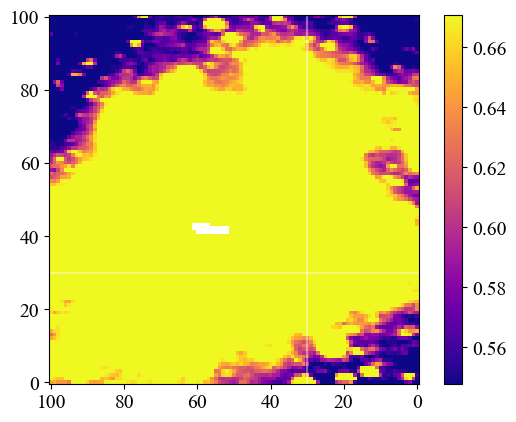

In [183]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.1, vmax=1., cmap='plasma', origin='lower',
          extent = [-0.002*50*60, 0.002*50*60, -0.002*50*60, 0.002*50*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('R CrA Ice Absorption')
rlist = [285.4602500, 285.4802500, 285.5102500]
dlist = [-36.9362500, -36.9052500, -36.8852500]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/R-CrA-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

### old:

In [1458]:
rlist = [285.4102500, 285.4602500, 285.4502500, 285.4302500]
dlist = [-36.9602500, -36.9362500, -36.9362500, -36.9362500]
#dlist = [-36.945, -36.945, -36.945, -36.945]
w1, f1, e1 = spectrum(rlist[0], dlist[0], 'RCrA-SPHEREx')
w2, f2, e2 = spectrum(rlist[1], dlist[1], 'RCrA-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'RCrA-SPHEREx')
w4, f4, e4 = spectrum(rlist[3], dlist[3], 'RCrA-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
195.0497206577657 17

tau =  0.1452531897714684
tau =  0.06746347303661047
tau =  0.11071981125861066
tau =  0.15984463841153768


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/169193159.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


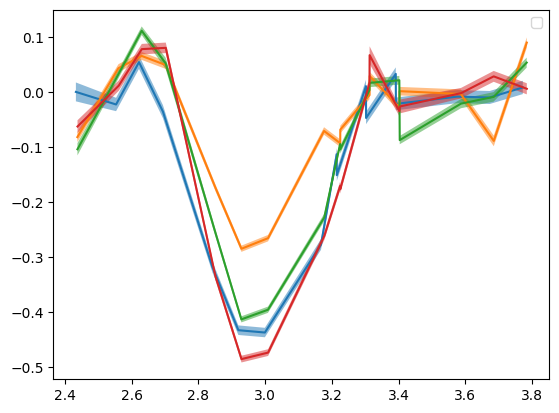

In [1460]:
#plt.plot(w1, f1/np.nanmedian(f1[:4]), marker='d')
#plt.plot(w1, f1, marker='d')
#plt.plot(w1, f1/np.nanmedian(f1[:5]), marker='d')
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C
#f1[-5] = np.nan
#plt.plot(w2, f2/np.nanmedian(f2[:5]), marker='d', label='Closest to centre')
for ww, ff, ee in zip([w1, w2, w3, w4], [f1, f2, f3, f4], [e1, e2, e3, e4]):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    mask = np.where(((wv <= 2.95) | (wv >= 3.05)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[~mask] / cont_fit(wv[~mask],*popt))
    #plt.plot(wv, (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:5]), marker='d')
    print('tau = ',np.nanmean(tau_all))

#plt.plot(w3, f3/np.nanmedian(f3[:5]), marker='d', label='Middle')
#plt.plot(w4, f4/np.nanmedian(f4[:5]), marker='d', label='Farthest')
#plt.plot(w1, f1/np.nanmedian(f1[:5]), marker='d', label='Outside')
plt.legend()

## LDN 260 - prestellar:

In [168]:
ra_points = np.arange(251.7885000-0.002*30, 251.7885000+0.002*30, 0.002)
dec_points = np.arange(-9.5835556-0.002*30, -9.5835556+0.002*30, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'LDN260-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

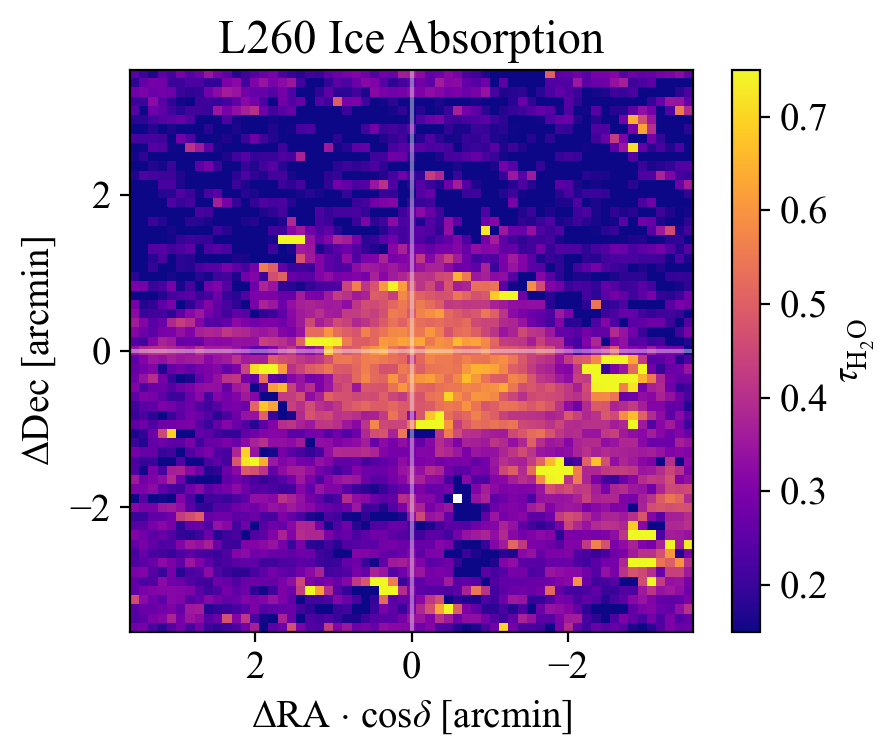

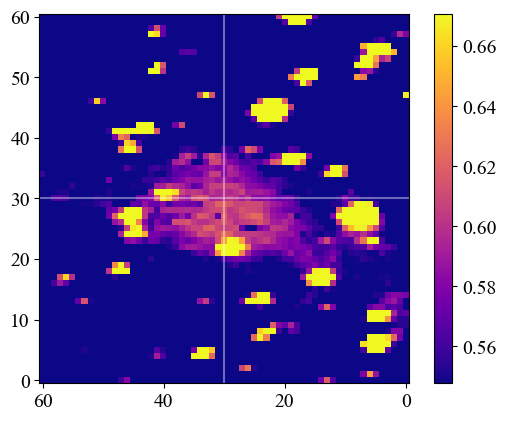

In [171]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.15, vmax=0.75, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('L260 Ice Absorption')
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/L260-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

### old:

In [1442]:
rlist = [251.725, 251.7425000, 251.78, 251.78]   
dlist = [-9.62, -9.6055556, -9.595, -9.595]
rlist = [251.7885000, 251.799, 251.810]   
dlist = [-9.5835556, -9.578, -9.570]
#w1, f1, e1 = spectrum(rlist[0], dlist[0], 'LDN260-SPHEREx')
#w2, f2, e2 = spectrum(rlist[1], dlist[1], 'LDN260-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'LDN260-SPHEREx')


INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
933.4886295830856 92

tau =  0.23938237550337071
tau =  0.18513342189743356
tau =  0.13321710106882342


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/4130860114.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


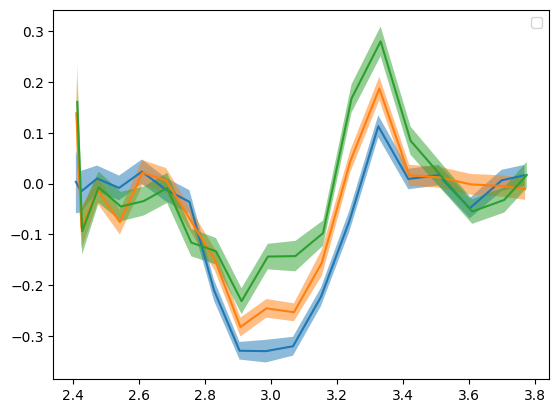

In [1443]:
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C
#f3[10] = np.nan
#plt.plot(w2, f2/np.nanmedian(f2[:5]), marker='d', label='Closest to centre')
for ww, ff, ee in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3]):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    print('tau = ',-np.log10(np.nanmin(fv) / cont_fit(wv[np.nanargmin(fv)],*popt)))

if 0:
    plt.plot(w1, f1/np.nanmedian(f1[-7:]), marker='', label='Centre')
    plt.fill_between(w1, (f1-e1)/np.nanmedian(f1[-7:]), (f1+e1)/np.nanmedian(f1[-7:]), color='C0', alpha=0.5)
    plt.plot(w2, f2/np.nanmedian(f2[-7:]), marker='', label='Farthest')
    plt.fill_between(w2, (f2-e2)/np.nanmedian(f2[-7:]), (f2+e2)/np.nanmedian(f2[-7:]), color='C1', alpha=0.5)
    plt.plot(w3, f3/np.nanmedian(f3[-7:]), marker='', label='Outside')
    plt.fill_between(w3, (f3-e3)/np.nanmedian(f3[-7:]), (f3+e3)/np.nanmedian(f3[-7:]), color='C2', alpha=0.5)
plt.legend()

In [1423]:
f1/e1

array([ 171.99542,  387.19446,  976.62305, 1028.5131 , 1045.5842 ,
       1041.9741 ,  981.05695,  918.1543 ,  993.29346,  464.86633,
        750.05676,  959.9347 ,  912.5521 , 1081.9872 , 1070.8441 ,
       1065.0919 ,  988.73645,  902.15826, 1056.3855 ], dtype=float32)

## L1521 - faint YSO:

In [197]:
ra_points = np.arange(67.1620833-0.0023*30, 67.1620833+0.0023*30, 0.0023)
dec_points = np.arange(26.8607222-0.002*30, 26.8607222+0.002*30, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'L1521-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

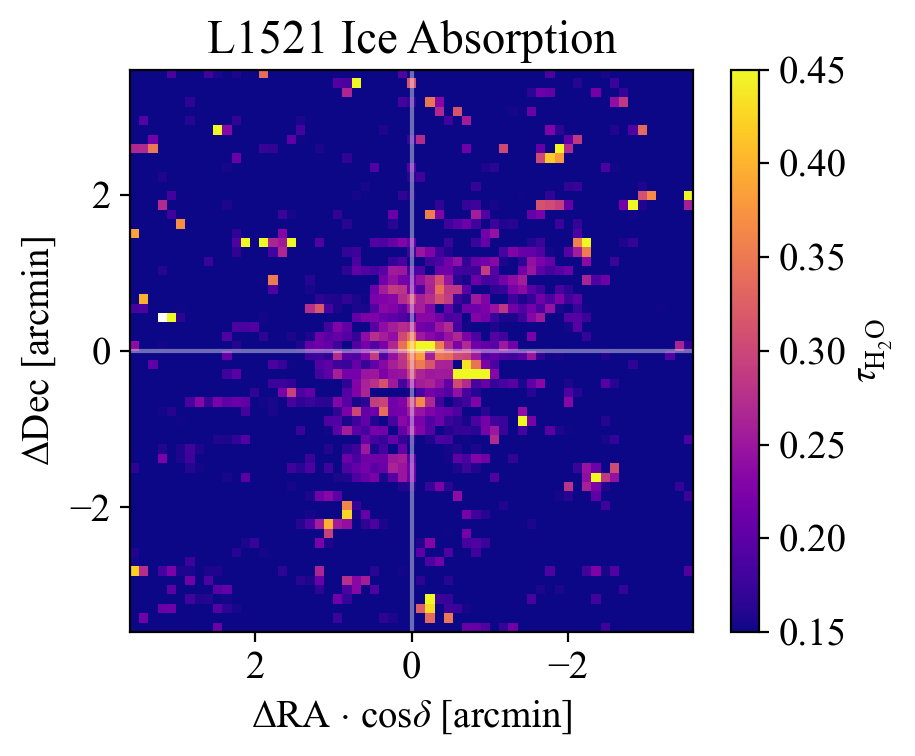

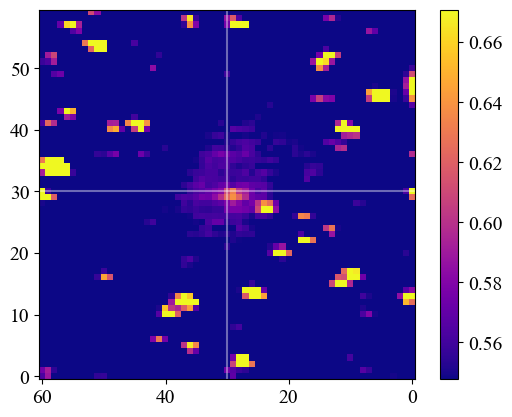

In [201]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.15, vmax=0.45, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('L1521 Ice Absorption')
rlist = [67.1620833, 67.1660833, 67.1730833, ]
dlist = [26.8607222, 26.8547222, 26.8457222, ]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/L1521-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

### Old:

In [1454]:
rlist = [67.1620833, 67.1660833, 67.1560833, ]
dlist = [26.8607222, 26.8547222, 26.8647222, ]

w1, f1, e1 = spectrum(rlist[0], dlist[0], 'L1521-SPHEREx')
w2, f2, e2 = spectrum(rlist[1], dlist[1], 'L1521-SPHEREx')
w3, f3, e3 = spectrum(rlist[2], dlist[2], 'L1521-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1294.7144263262578 1

tau =  0.16721459037084246
tau =  0.05811441888089898
tau =  0.07108667074760291


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/3913209546.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


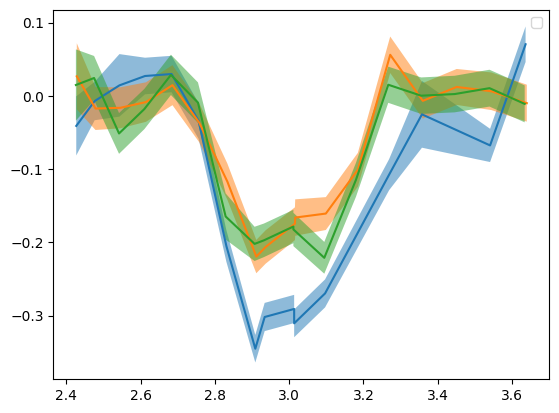

In [1456]:
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C
f1[-3] = f1[-6] = np.nan
#f3[5] = np.nan
#plt.plot(w2, f2/np.nanmedian(f2[:5]), marker='d', label='Closest to centre')
for ww, ff, ee in zip([w1, w2, w3], [f1, f2, f3], [e1, e2, e3]):
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.35))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    mask = np.where(((wv <= 2.95) | (wv >= 3.05)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[~mask] / cont_fit(wv[~mask],*popt))
    #plt.plot(wv, (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:5]), marker='d')
    print('tau = ',np.nanmean(tau_all))

if 0:
    plt.plot(w1, f1/np.nanmedian(f1[:6]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[:6]), marker='d', label='Farthest')
    plt.plot(w3, f3/np.nanmedian(f3[:6]), marker='d', label='Outside')
plt.legend()

## Ced 110 - moderate YSO:

In [189]:
ra_points = np.arange(166.6906667-0.008*30, 166.6906667+0.008*30, 0.008)
dec_points = np.arange(-77.3758333-0.002*30, -77.3758333+0.002*30, 0.002)

tau, cont = spectrum(ra_points, dec_points, 'Ced110-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
INFO: 
             

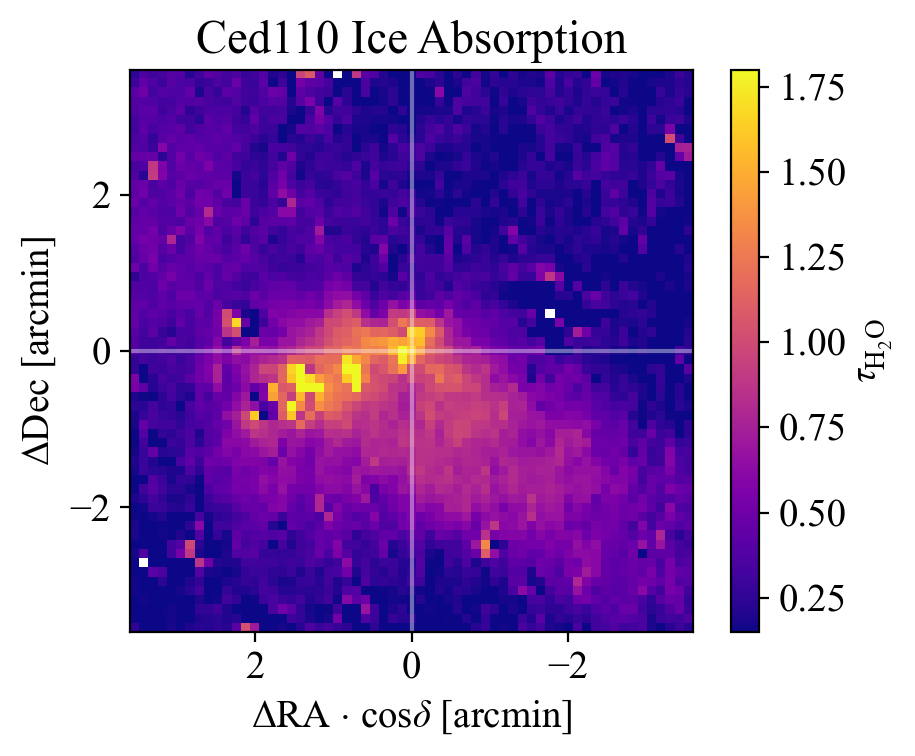

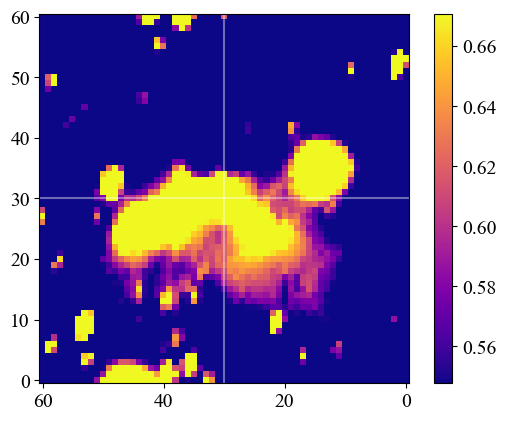

In [191]:
tt = tau.copy()
tt[np.where(tt==0)] = np.nan

plt.figure(figsize=(5,4), dpi=200)
plt.imshow(np.array(tt.T), vmin=0.15, vmax=1.8, cmap='plasma', origin='lower',
          extent = [-0.002*30*60, 0.002*30*60, -0.002*30*60, 0.002*30*60])
plt.colorbar(label=r'$\tau_{\mathrm{H_2O}}$')
plt.axhline(0, color='white', alpha=0.4)
plt.axvline(0, color='white', alpha=0.4)
plt.xlabel(r'$\Delta$RA $\cdot$ cos$\delta$ [arcmin]')
plt.ylabel(r'$\Delta$Dec [arcmin]')
plt.gca().invert_xaxis()
plt.title('Ced110 Ice Absorption')
rlist = [76.0697917, 76.0567917, 76.0437917]
dlist = [25.18125, 25.19025, 25.20625]
ra0, dec0 = rlist[0], dlist[0]
for rr, dd in zip(rlist, dlist):
    rr1 = (rr-ra0) * 60 * np.cos(dd*np.pi/180)
    dd1 = (dd-dec0) * 60
    #plt.scatter(rr1, dd1, marker='x', color='limegreen', alpha=0.5)
plt.tight_layout()
plt.savefig('Paper1.1/Ced110-icemap.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

gn = 1/2
plt.imshow(np.array(cont.T)**gn, vmin=0.3**gn, vmax=0.45**gn, cmap='plasma', origin='lower')
plt.colorbar()
plt.axhline(30, color='white', alpha=0.4)
plt.axvline(30, color='white', alpha=0.4)
plt.gca().invert_xaxis()
plt.show()

# old:

In [116]:
rlist = [166.6906667, 166.7056667, 166.7206667, 166.7406667]   
dlist = [-77.3758333, -77.3728333, -77.3710333, -77.3643333]

#rlist = [166.7956667, 166.7956667, 166.7956667]   
#dlist = [-77.3960333, -77.3950333, -77.3900333]

w1, f1, e1 = spectrum(rlist[0], dlist[0], 'Ced110-SPHEREx')
#w2, f2, e2 = spectrum(rlist[1], dlist[1], 'Ced110-SPHEREx')
#w3, f3, e3 = spectrum(rlist[2], dlist[2], 'Ced110-SPHEREx')
#w4, f4, e4 = spectrum(rlist[3], dlist[3], 'Ced110-SPHEREx')

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]
1415.1187810994197 7

tau =  0.21399415107147474
tau =  0.1810299161296962
tau =  0.15777676800715784
tau =  0.00798549967245554


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_29016/3558234800.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


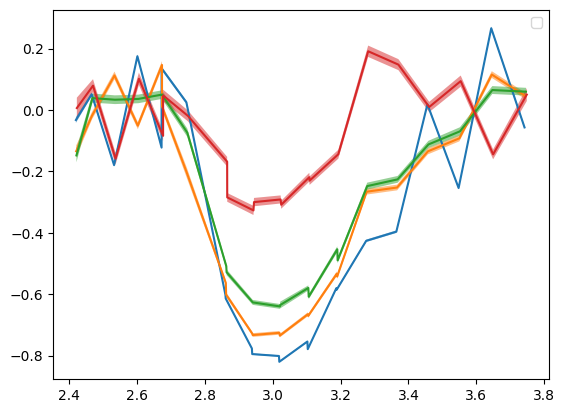

In [118]:
def cont_fit(w,A,B,C):
    return A*w**2 + B*w + C
#f1[0] = f2[0] = f3[0] = np.nan
#f4[10] = np.nan
#f3[5] = np.nan
#f2[10] = np.nan
#plt.plot(w2, f2/np.nanmedian(f2[:5]), marker='d', label='Closest to centre')
for ww, ff, ee in zip([w1, w2, w3, w4], [f1, f2, f3, f4], [e1, e2, e3, e4]):
    #continue
    wv, fv, ev = ww.copy(), ff.copy(), ee.copy()
    mask = np.isnan(fv)
    wv, fv, ev = wv[~mask], fv[~mask], ev[~mask]
    mask = np.where((wv <= 2.7) | (wv >= 3.4))[0]
    popt, pcov = curve_fit(cont_fit, wv[mask], fv[mask])
    #plt.plot(wv, cont_fit(wv, *popt)/np.nanmedian(fv[-7:]), color='k', lw=0.7)
    y1 = (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y2 = (fv-ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    y3 = (fv+ev-cont_fit(wv, *popt))/np.nanmedian(fv[:6])
    plt.plot(wv, y1, marker='')
    plt.fill_between(wv, y2, y3, alpha=0.5)
    mask = np.where(((wv <= 2.85) | (wv >= 3.15)) & ~np.isnan(fv))[0]
    tau_all = -np.log(fv[~mask] / cont_fit(wv[~mask],*popt))
    #plt.plot(wv, (fv-cont_fit(wv, *popt))/np.nanmedian(fv[:5]), marker='d')
    print('tau = ',np.nanmean(tau_all))

if 0:
    plt.plot(w1, f1/np.nanmedian(f1[:6]), marker='d', label='Centre')
    plt.plot(w2, f2/np.nanmedian(f2[:6]), marker='d', label='Middle')
    plt.plot(w3, f3/np.nanmedian(f3[:6]), marker='d', label='Outer')
    plt.plot(w4, f4/np.nanmedian(f4[:6]), marker='d', label='Outside')
plt.legend()

# Visualisation

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


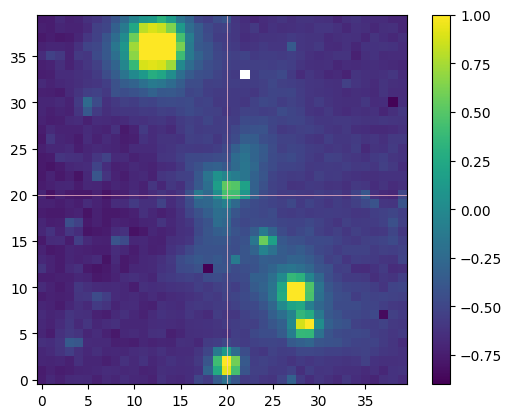

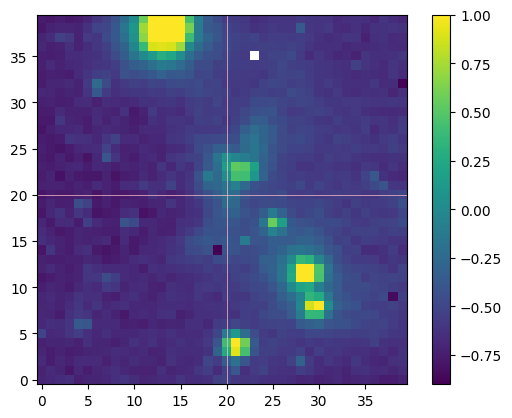

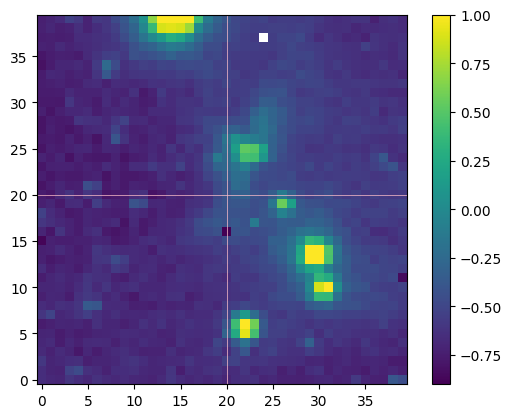

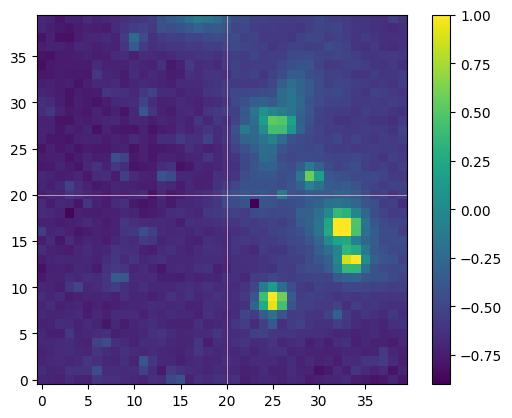

In [115]:
allfiles = glob.glob('L1521-SPHEREx/*.fits')
allfiles = glob.glob('Ced110-SPHEREx/*.fits')
#allfiles = glob.glob('CrA-151-SPHEREx/*.fits')

ww, ff = [], []

for a in allfiles[10:11]:
    hdulist = fits.open(a)
    img = hdulist[1].data
    wave = hdulist[6].data
    spectral_image_header = hdulist[1].header
    wcs = WCS(spectral_image_header)
    ra, dec = wcs.wcs.crval
    x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
    spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

    spectral_wcs.sip = None
    wl, bw = spectral_wcs.pixel_to_world(x, y)
    spectral_image = hdulist["IMAGE"]
    spectral_image_data = spectral_image.data
    (y, x) = np.indices(spectral_image.shape)
    spectral_coords = spectral_wcs.pixel_to_world(x, y)
    wavelength, bandwidth = spectral_coords

    coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
    #coord = SkyCoord(ra=294.2559167*u.deg, dec=7.5698889*u.deg, frame="icrs")
    #coord = SkyCoord(ra=53.3245*u.deg, dec=31.1589*u.deg, frame="icrs")
    #285.4852500 -36.9582500
    rlist = [67.1620833, 67.1680833, 67.1570833]
    dlist = [26.8664222, 26.8707222, 26.8587222]
    rlist = [67.1620833, 67.1660833, 67.1560833, 67.1720833]
    dlist = [26.8664222, 26.8547222, 26.8567222, 26.8767222]
    rlist = [285.4102500, 285.4602500, 285.4502500, 285.4302500]
    dlist = [-36.9602500, -36.9362500, -36.9362500, -36.9362500]
    rlist = [76.0697917, 76.0857917, 76.0997917]
    dlist = [25.18125, 25.17025, 25.14225]
    rlist = [76.0324167, 76.0434167, 76.0544167]   
    dlist = [32.7311667, 32.7301667, 32.7281667]
    rlist = [76.0697917, 76.0857917, 76.0997917]
    dlist = [25.18125, 25.17025, 25.14225]
    rlist = [166.6906667, 166.7056667, 166.7206667, 166.7406667]   
    dlist = [-77.3758333, -77.3728333, -77.3710333, -77.3643333]
    for rr,dd in zip(rlist,dlist):
        coord = SkyCoord(ra=rr*u.deg, dec=dd*u.deg, frame="icrs")
        #294.2529167    7.5688889
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        flux = img[int(y+0.5),p1:p2]
        lam = wavelength.value[int(y+0.5),p1:p2]
        sm = 2
        flux = ndimage.gaussian_filter1d(flux, sm)
        ww.append(np.mean(lam))
        ff.append(flux)
    
        x1, x2 = int(x-20), int(x+20)
        y1, y2 = int(y-20), int(y+20)
        arr = img.copy()[y1:y2, x1:x2]
        plt.imshow(np.log10(arr), vmin=-0.9, vmax=1, origin='lower')
        #plt.imshow(np.array(arr), vmin=0., vmax=0.55, origin='lower')
        plt.colorbar()
        
        plt.axvline(20, color='pink', lw=0.5)
        plt.axhline(20, color='pink', lw=0.5)
        plt.show()

## Old Code:

INFO: 
                Inconsistent SIP distortion information is present in the FITS header and the WCS object:
                SIP coefficients were detected, but CTYPE is missing a "-SIP" suffix.
                astropy.wcs is using the SIP distortion coefficients,
                therefore the coordinates calculated here might be incorrect.

                If you do not want to apply the SIP distortion coefficients,
                please remove the SIP coefficients from the FITS header or the
                WCS object.  As an example, if the image is already distortion-corrected
                (e.g., drizzled) then distortion components should not apply and the SIP
                coefficients should be removed.

                While the SIP distortion coefficients are being applied here, if that was indeed the intent,
                for consistency please append "-SIP" to the CTYPE in the FITS header or the WCS object.

                 [astropy.wcs.wcs]


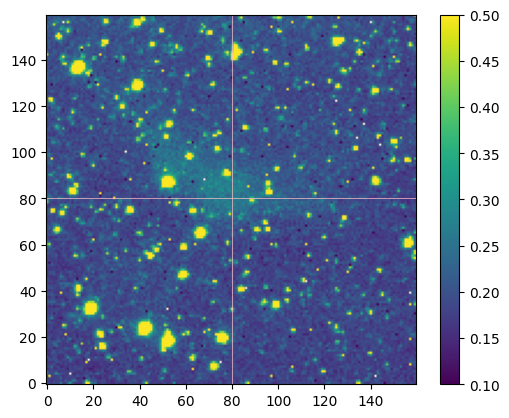

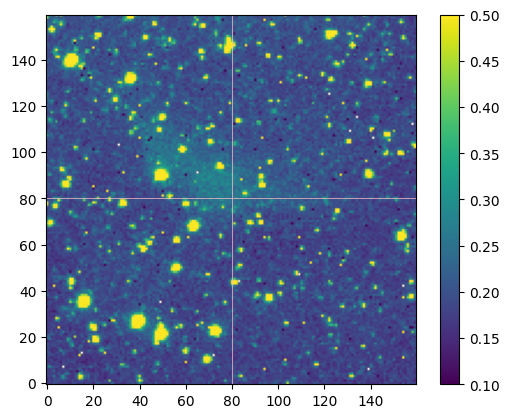

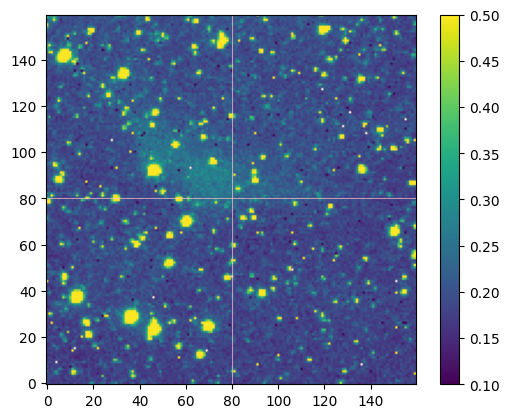

In [1008]:
allfiles = glob.glob('LDN260-SPHEREx/*.fits')
#allfiles = glob.glob('RCrA-SPHEREx/*.fits')
#allfiles = glob.glob('CrA-151-SPHEREx/*.fits')

ww, ff = [], []

for a in allfiles[5:6]:
    hdulist = fits.open(a)
    img = hdulist[1].data
    wave = hdulist[6].data
    spectral_image_header = hdulist[1].header
    wcs = WCS(spectral_image_header)
    ra, dec = wcs.wcs.crval
    x, y = wcs.world_to_pixel(SkyCoord(ra=ra, dec=dec, unit="deg"))
    spectral_wcs = WCS(header=hdulist["IMAGE"].header, fobj=hdulist, key="W")

    spectral_wcs.sip = None
    wl, bw = spectral_wcs.pixel_to_world(x, y)
    spectral_image = hdulist["IMAGE"]
    spectral_image_data = spectral_image.data
    (y, x) = np.indices(spectral_image.shape)
    spectral_coords = spectral_wcs.pixel_to_world(x, y)
    wavelength, bandwidth = spectral_coords

    coord = SkyCoord(ra=287.5840417*u.deg, dec=-37.1408333*u.deg, frame="icrs")
    #coord = SkyCoord(ra=294.2559167*u.deg, dec=7.5698889*u.deg, frame="icrs")
    #coord = SkyCoord(ra=53.3245*u.deg, dec=31.1589*u.deg, frame="icrs")
    #285.4852500 -36.9582500
    rlist = [238.5408333,238.5458333,238.5478333]   
    dlist = [-2.8263333,-2.8103333,-2.803333]
    rlist = [238.5408333,238.5328333,238.5198333]   
    dlist = [-2.8263333,-2.8263333,-2.8233333]
    rlist = [76.0617917, 76.0537917, 76.0237917]
    dlist = [25.18725, 25.20725, 25.23525]
    rlist = [251.7925000, 251.799, 251.805]   
    dlist = [-9.5835556, -9.578, -9.575]
    for rr,dd in zip(rlist,dlist):
        coord = SkyCoord(ra=rr*u.deg, dec=dd*u.deg, frame="icrs")
        #294.2529167    7.5688889
        x, y = wcs.world_to_pixel(coord)
        
        img = hdulist[1].data
        arr = img.copy()
    
        p1, p2 = int(x-80), int(x+80)
        flux = img[int(y+0.5),p1:p2]
        lam = wavelength.value[int(y+0.5),p1:p2]
        sm = 2
        flux = ndimage.gaussian_filter1d(flux, sm)
        ww.append(np.mean(lam))
        ff.append(flux)
    
        x1, x2 = int(x-80), int(x+80)
        y1, y2 = int(y-80), int(y+80)
        arr = img.copy()[y1:y2, x1:x2]
        #plt.imshow(np.log10(arr), vmin=-0.7, vmax=-0.3, origin='lower')
        plt.imshow(np.array(arr), vmin=0.1, vmax=0.5, origin='lower')
        plt.colorbar()
        
        plt.axvline(80, color='pink', lw=0.5)
        plt.axhline(80, color='pink', lw=0.5)
        plt.show()

In [769]:
rlist, dlist

([76.0617917, 76.0477917, 76.0337917],
 [25.18725, 25.201249999999998, 25.215249999999997])

In [427]:
ff = np.array(ff)
ff = ff[np.argsort(ww),:]
ww = np.sort(ww)

s1, s2 =30,31
ff[10,:] = (ff[9,:]+ff[11,:]) / 2
#ff[10,:] = np.nan
s=1

c1, c2, c3 = 71,81,90
for ind, lbl in zip([c1, c2, c3], ['left edge', 'centre', 'right edge']):
    frac = (ind-s1) / (s2-s1)
    r, g, b = frac, 0, 1-frac
    #plt.plot(ww, ff[:,ind]/np.nanmedian(ff[7:13,ind]), label=lbl, marker='d')
    plt.plot(ww, ff[:,ind]/np.nanmedian(ff[:4,ind]), label=lbl, marker='d')
#plt.axvline(ww[10], color='k')
plt.xlabel('Wavelength um')
plt.ylabel('Normalised flux')
#plt.ylim(0,2)
plt.legend()
plt.show()


x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()[y1:y2, x1:x2]
plt.imshow(arr, vmin=0, vmax=1., origin='upper')
plt.colorbar()

[plt.axvline(a, color='pink') for a in [c1, c2, c3]]
plt.axhline(80, color='pink')
plt.show()

IndexError: index 9 is out of bounds for axis 0 with size 4

## Compare with ice absorption in known starless and protostellar cores and see which matches 

## -- bigger idea: look at ice absorption patterns in multiple cores of each type and try to find differentiating factor

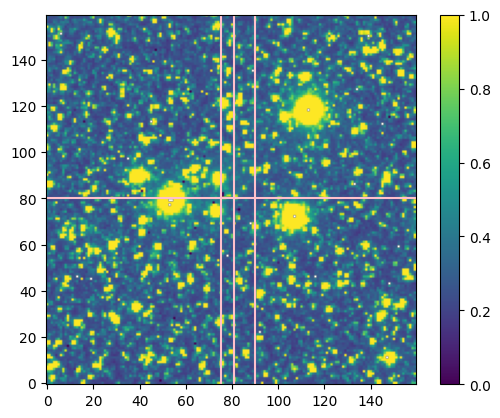

In [104]:
x1, x2 = int(x-80), int(x+80)
y1, y2 = int(y-80), int(y+80)
arr = img.copy()[y1:y2, x1:x2]
plt.imshow(arr, vmin=0, vmax=1., origin='lower')
plt.colorbar()

[plt.axvline(a, color='pink') for a in [75,81,90]]
plt.axhline(80, color='pink')

# Integrate Flux:

## Older codes:

In [495]:
quad(pathlength, 0, 0.01, args=(10,0.01,1))

(0.0009901478633121998, 1.0992849556326065e-17)

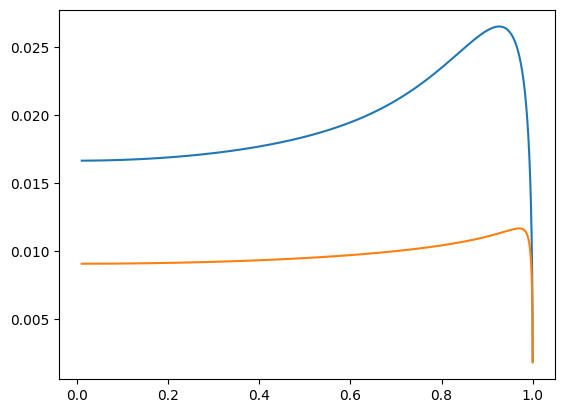

In [721]:
from scipy.integrate import quad

def pathlength_los(u, R, x, R0):
    r = R*np.cos(x)/np.cos(u)
    rho_R = R0**2 / (r**2 + R0**2)
    dl = r / np.cos(u)
    r_evap = R0 * 1
    width = R0 * 0.1
    #ice_abs = 0.75 + 0.25*np.tanh((r - r_evap) / width)
    return rho_R * dl

def pathlength_central(u, R0):
    rho_R = R0**2 / (u**2 + R0**2)
    return rho_R

g = 0.0

def f(t, x, R, R0, tau_h2o, tau_cont, ext_fact):
    r = R*np.cos(x)/np.cos(t)
    pcen = quad(pathlength_central, 0, r, args=(R0,))[0]
    lum_R = np.exp(-tau_cont*pcen) / r**2 + ext_fact * np.exp(-tau_cont * (ptot-pcen))
    angle_factor = (1-g**2) / (1 + g**2 - 2*g*np.sin(t))**1.5
    rho_R = R0**2 / (r**2 + R0**2)
    dV = r / np.cos(t)
    plos = R * (np.sin(x) + np.sin(t))
    plos = quad(pathlength_los, t, x, args=(R, x, R0))[0]
    absorption = np.exp(-(tau_h2o + tau_cont)*plos)
    return lum_R * rho_R * angle_factor * dV * absorption

R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 50, 30, 1

#R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 5, 1, 1
ptot = quad(pathlength_central, 0, R, args=(R0,))[0]

def continuum(t, x):
    return f(t, x, R=R, R0=R0, tau_h2o=0, tau_cont=tau_cont, ext_fact = ext_fact)

def ice(t, x):
    return f(t, x, R=R, R0=R0, tau_h2o=tau_h2o, tau_cont=tau_cont, ext_fact = ext_fact)

x = np.linspace(0.01,1.56,1000)
cc = np.array([quad(continuum, -xl, xl, args=(xl,))[0] for xl in x])
hh = np.array([quad(ice, -xl, xl, args=(xl,))[0] for xl in x])
plt.plot(np.cos(x), cc, marker='')
plt.plot(np.cos(x), hh, marker='')
#plt.yscale('log')

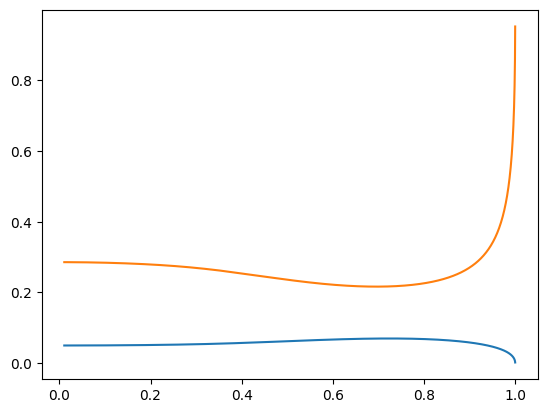

In [720]:
plt.plot(np.cos(x), cc, marker='')
plt.plot(np.cos(x), hh/cc, marker='')
#plt.yscale('log')

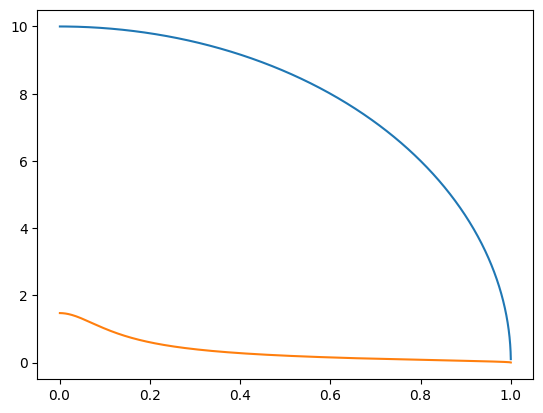

In [598]:
t = 0.
plos1 = [R * (np.sin(x) + np.sin(t)) for x in np.linspace(0.01,1.57,1000)]
plos2 = [quad(pathlength_los, t, x, args=(R, x, R0))[0] for x in np.linspace(0.01,1.57,1000)]
xr = np.linspace(0.01,1.57,1000)
plt.plot(np.cos(xr), plos1)
plt.plot(np.cos(xr), plos2)

## YSO Illuminated Core:

/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_6277/4265588272.py:64: RuntimeWarning: invalid value encountered in divide
  ratio = I_ice / I_cont


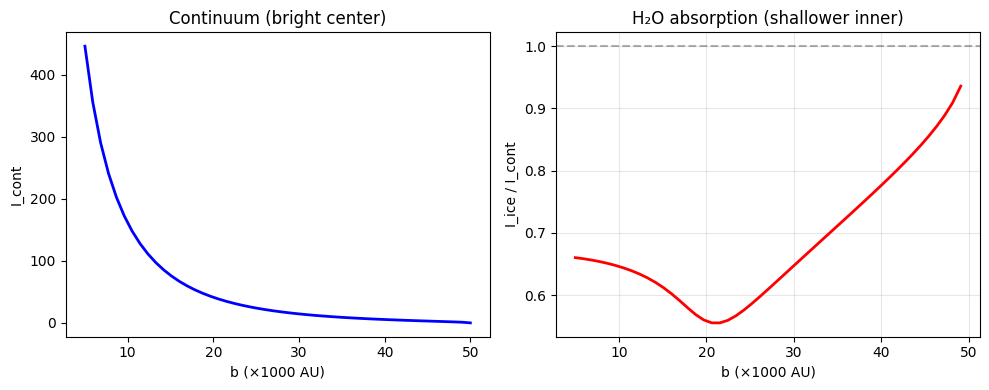

In [1228]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

R_cloud = 0.05
R0      = 0.02
tau_cont0 = 2e-3 * 1e3
tau_ice0  = 50e-3 * 1e3

# Ice depletion parameters
r_warm = 0.02  # pc, inner warm region
width  = 0.003  # pc, transition width

def rho(r, R0=R0):
    return R0**2 / (r**2 + R0**2)

def ice_factor(r):
    """Ice abundance: depleted inside r_warm, full outside."""
    return 0.5 * (1 + np.tanh((r - r_warm)/width))

def tau_radial(r, tau_cont):
    if r <= 0:
        return 0.0
    return tau_cont * quad(lambda rp: rho(rp), 0, r)[0]

def tau_los(b, s, tau_cont, tau_ice):
    s_max = np.sqrt(max(R_cloud**2 - b**2, 0))
    if s >= s_max:
        return 0.0
    def integrand(sp):
        r = np.sqrt(b**2 + sp**2)
        return rho(r) * (tau_cont + tau_ice * ice_factor(r))  # ← ice gradient
    return quad(integrand, s, s_max)[0]

def emissivity(r, tau_cont):
    if r == 0:
        return 0.0
    J_r = np.exp(-tau_radial(r, tau_cont)) / r**2
    return rho(r) * J_r

def intensity_continuum(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, 0)
        return j * np.exp(-tau_l)
    return quad(integrand, -s_max, s_max)[0]

def intensity_ice(b):
    if b >= R_cloud:
        return 0.0
    s_max = np.sqrt(R_cloud**2 - b**2)
    def integrand(s):
        j = emissivity(np.sqrt(b**2 + s**2), tau_cont0)
        tau_l = tau_los(b, s, tau_cont0, tau_ice0)
        return j * np.exp(-tau_l)
    return quad(integrand, -s_max, s_max)[0]

b_vals = np.linspace(0.005, R_cloud, 50)
I_cont = np.array([intensity_continuum(b) for b in b_vals])
I_ice  = np.array([intensity_ice(b)     for b in b_vals])
ratio = I_ice / I_cont

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,4))
ax1.plot(b_vals*1000, I_cont, 'b-', lw=2)
ax1.set_xlabel("b (×1000 AU)")
ax1.set_ylabel("I_cont")
ax1.set_title("Continuum (bright center)")

ax2.plot(b_vals*1000, ratio, 'r-', lw=2)
ax2.axhline(1.0, color='k', ls='--', alpha=0.3)
ax2.set_xlabel("b (×1000 AU)")
ax2.set_ylabel("I_ice / I_cont")
ax2.set_title("H₂O absorption (shallower inner)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Scattering/coreshine illuminated core:

/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_49826/3180857611.py:64: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tau_in[i] = np.trapz(rhoeff, s_use[:i+1]) * kappa_ext
/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_49826/3180857611.py:73: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  tau_out[i] = np.trapz(rhoeff, s_use[i:]) * kappa_ext
/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_49826/3180857611.py:84: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  I.append(np.trapz(contrib, s_use))


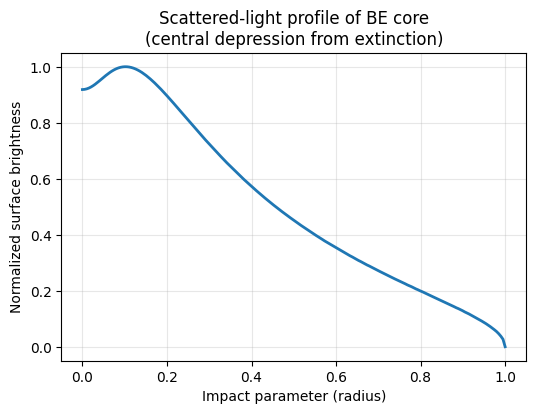

In [138]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Grid and geometry
# -----------------------------
R_max = 1.0          # core radius (arbitrary units)
nr = 500
ns = 800

r = np.linspace(0, R_max, nr)
b_vals = np.linspace(0, R_max, 200)

# Line-of-sight coordinate
s = np.linspace(-R_max, R_max, ns)

# -----------------------------
# Bonnor–Ebert–like density profile
# (analytic approximation)
# -----------------------------
rho0 = 1.0
r0 = 0.1             # flat inner radius
rho = rho0 / (1 + (r / r0)**2)
rhosat = rho0 * 1e6

# Interpolation helper
def rho_interp(x):
    return np.interp(x, r, rho, left=0, right=0)

# -----------------------------
# Dust properties
# -----------------------------
kappa_abs = 2      # absorption opacity
kappa_sca = 3      # scattering opacity
kappa_ext = kappa_abs + kappa_sca
albedo = kappa_sca / kappa_ext

# -----------------------------
# Optical depth integrals
# -----------------------------
def tau_along_path(r_vals):
    """Cumulative optical depth along LOS"""
    return np.cumsum(rho_interp(r_vals)) * kappa_ext * (2 * R_max / ns)

# -----------------------------
# Surface brightness
# -----------------------------
I = []

for b in b_vals:
    r_los = np.sqrt(b**2 + s**2)
    inside = r_los <= R_max

    r_use = r_los[inside]
    s_use = s[inside]

    # Optical depth from surface -> scattering point
    tau_in = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[:i+1]**2)
        rhor = rho_interp(path)
        #tau_in[i] = np.trapz(rhor, s_use[:i+1]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+rhor/rhosat) + albedo)
        tau_in[i] = np.trapz(rhoeff, s_use[:i+1]) * kappa_ext

    # Optical depth from scattering point -> observer
    tau_out = np.zeros_like(r_use)
    for i in range(len(r_use)):
        path = np.sqrt(b**2 + s_use[i:]**2)
        rhor = rho_interp(path)
        #tau_out[i] = np.trapz(rhor, s_use[i:]) * kappa_ext
        rhoeff = rhor * ((1-albedo) / (1+rhor/rhosat) + albedo)
        tau_out[i] = np.trapz(rhoeff, s_use[i:]) * kappa_ext

    # Incident radiation field
    J_inc = np.exp(-tau_in)

    # Scattered emissivity
    emissivity = rho_interp(r_use) * kappa_sca * J_inc

    # Attenuation after scattering
    contrib = emissivity * np.exp(-tau_out)

    I.append(np.trapz(contrib, s_use))

I = np.array(I)
I_cont = I.copy()

# Normalize
I /= I.max()

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(b_vals, I, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
plt.grid(alpha=0.3)
plt.show()


/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_49826/1851352628.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(b_vals, I_ice/I_cont, lw=2)
/var/folders/73/5cpbpjm96nn4n2mcc500_zbh0000gn/T/ipykernel_49826/1851352628.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(b_vals, I_ice2/I_cont, lw=2)


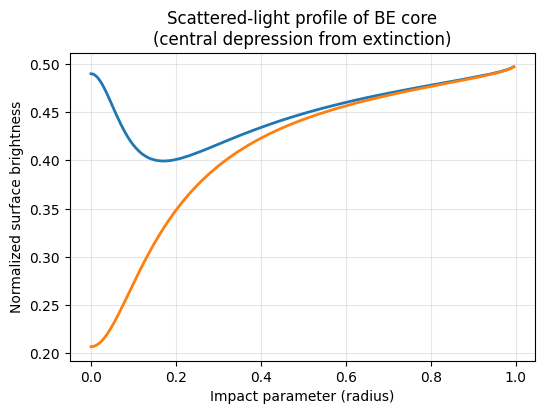

In [139]:
plt.figure(figsize=(6,4))
plt.plot(b_vals, I_ice/I_cont, lw=2)
plt.plot(b_vals, I_ice2/I_cont, lw=2)
plt.xlabel("Impact parameter (radius)")
plt.ylabel("Normalized surface brightness")
plt.title("Scattered-light profile of BE core\n(central depression from extinction)")
plt.grid(alpha=0.3)
plt.show()


## Older codes:

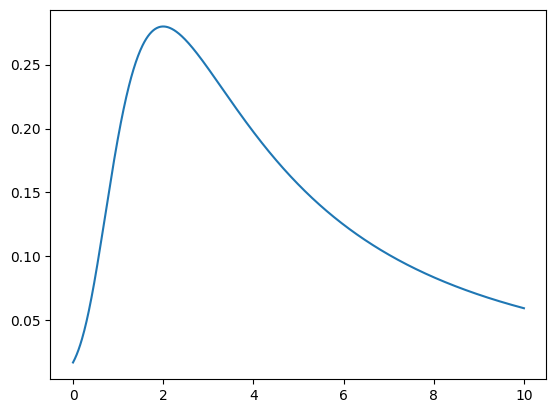

In [624]:
ptot = quad(pathlength_central, 0, R, args=(R0,))[0]
pcen = np.array([quad(pathlength_central, 0, r, args=(R0,))[0] for r in np.linspace(0,R,1000)])

R, R0, tau_h2o, tau_cont, ext_fact = 10, 1, 50, 4, 6
rho_R = np.array([R0**2 / (r**2 + R0**2) for r in np.linspace(0,R,1000)])
lum_R = np.exp(-tau_cont*pcen) / r**2 + ext_fact * np.exp(-tau_cont * (ptot-pcen))

plt.plot(np.linspace(0,R,1000), lum_R*rho_R)

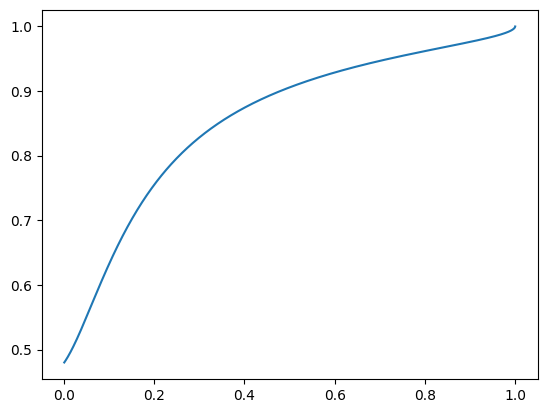

In [602]:
plt.plot(np.cos(x), hh/cc, marker='')
#plt.yscale('log')

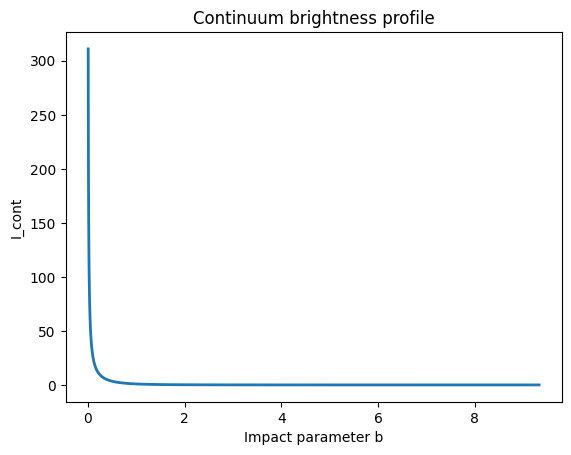

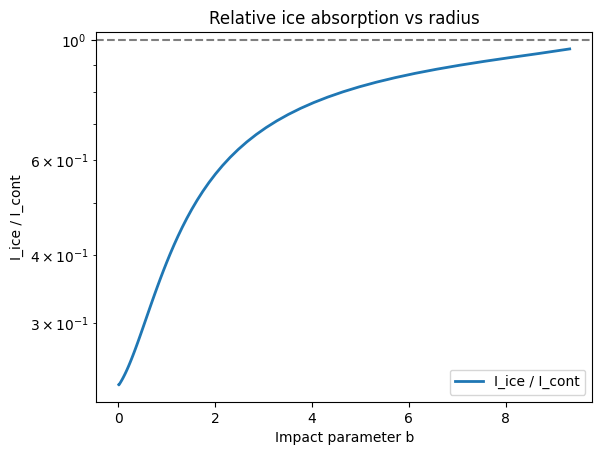

In [542]:
import numpy as np
from scipy.integrate import quad
import matplotlib.pyplot as plt

# Global parameters (you can tune these)
R   = 10.0   # outer radius (arbitrary units)
R0  = 1.0    # density scale radius
r_evap = R0/100.0
width  = R0/1000.0

# ------------------------------
# Basic radial profiles
# ------------------------------

def rho(r, R0=R0):
    """Spherical density profile rho(r) = R0^2 / (r^2 + R0^2)."""
    return R0**2 / (r**2 + R0**2)

def ice_factor(r):
    """0 inside r_evap, ~1 outside, smoothed with tanh."""
    return 0.5 * (1.0 + np.tanh((r - r_evap)/width))

# ------------------------------
# Optical depths
# ------------------------------

def tau_radial(r, tau_cont):
    """
    Radial continuum optical depth from center to radius r.
    tau_cont is an overall scaling factor (per unit 'rho' * dr).
    """
    if r <= 0:
        return 0.0
    integrand = lambda rp: rho(rp)
    tau = tau_cont * quad(integrand, 0.0, r, epsabs=1e-5, epsrel=1e-4)[0]
    return tau

def tau_los(b, s, tau_cont, tau_h2o):
    """
    LOS optical depth from position (b,s) to the near side (s -> +sqrt(R^2 - b^2)).
    b: impact parameter, s: current LOS position (negative behind, positive front).
    """
    s_max = np.sqrt(max(R**2 - b**2, 0.0))
    if s >= s_max:
        return 0.0

    def integrand(sp):
        r = np.sqrt(b**2 + sp**2)
        return rho(r) * (tau_cont + tau_h2o * ice_factor(r))

    tau = quad(integrand, s, s_max, epsabs=1e-5, epsrel=1e-4)[0]
    return tau

# ------------------------------
# Local emissivity from central source
# ------------------------------

def emissivity(r, tau_cont):
    """
    Local emissivity j(r) ∝ rho(r) * J(r),
    where J(r) ∝ exp(-tau_radial) / r^2 is the attenuated central intensity.
    """
    if r == 0:
        return 0.0
    J_r = np.exp(-tau_radial(r, tau_cont)) / r**2
    return rho(r) * J_r

# ------------------------------
# Specific intensity at impact parameter b
# ------------------------------

def intensity(b, tau_h2o, tau_cont):
    """
    Compute I(b) by integrating along the line of sight through the envelope.
    b: impact parameter (0 = center, up to R).
    """
    if b >= R:
        return 0.0

    # s ranges from -s_max (far side) to +s_max (near side)
    s_max = np.sqrt(R**2 - b**2)

    def integrand(s):
        r = np.sqrt(b**2 + s**2)
        j_r = emissivity(r, tau_cont)
        # attenuation from this point to the observer
        tau_l = tau_los(b, s, tau_cont, tau_h2o)
        return j_r * np.exp(-tau_l)

    I, _ = quad(integrand, -s_max, s_max, epsabs=1e-5, epsrel=1e-4)
    return I

# ------------------------------
# Convenience wrappers for continuum vs ice
# ------------------------------

def continuum_intensity(b):
    # very small continuum opacity to keep envelope optically thin-ish
    return intensity(b, tau_h2o=0.0, tau_cont=1e-4)

def ice_intensity(b):
    return intensity(b, tau_h2o=1.0, tau_cont=1e-4)

# ------------------------------
# Example: center-to-edge profile
# ------------------------------

# impact parameter grid from center (0) to edge (R)
b_vals = np.logspace(-2, np.log10(R), 100)

I_cont = np.array([continuum_intensity(b) for b in b_vals])
I_ice  = np.array([ice_intensity(b) for b in b_vals])

# avoid division by zero; restrict to inside envelope
mask = I_cont > 0
b_plot  = b_vals[mask]
ratio   = I_ice[mask] / I_cont[mask]

plt.figure()
plt.plot(b_plot, I_cont[mask], label="Continuum", lw=2)
plt.xlabel("Impact parameter b")
plt.ylabel("I_cont")
plt.title("Continuum brightness profile")

plt.figure()
plt.plot(b_plot, ratio, label="I_ice / I_cont", lw=2)
plt.xlabel("Impact parameter b")
plt.ylabel("I_ice / I_cont")
plt.yscale('log')
plt.title("Relative ice absorption vs radius")
plt.axhline(1.0, color='k', ls='--', alpha=0.5)
plt.legend()
plt.show()
